Features are ready. Now we build the models. The goal is to predict each customer's 3-month forward revenue using the features we engineered from their transaction history. We'll train and compare a few regression models, tune the best ones, and pick a winner based on RMSE, MAE, and R². The final output is a scored table with each customer's predicted LTV and their assigned tier.

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score
import joblib

In [2]:
df = pd.read_csv("features.csv")
scaled_df = pd.read_csv("features_scaled.csv")
display(df.head())
print("\nScaled data:")
display(scaled_df.head())

,log_Recency,log_Frequency,log_Monetary,log_avg_order_value,log_avg_days_between_orders,log_tenure_days,log_return_rate,log_unique_products,log_unique_months_active,log_last_month_revenue,log_ltv_3m,Customer ID
0,4.158883,2.484907,5.923881,2.509501,1.945910,5.560682,0.223144,3.295837,1.609438,0.0,0.000000,12346
1,4.653960,1.098612,7.146394,3.331840,0.330242,4.820282,0.091808,3.871201,1.098612,0.0,7.246810,12349
2,4.624973,0.693147,6.192792,3.143780,0.000000,4.624973,0.000000,3.135494,0.693147,0.0,0.000000,12355
3,4.442651,1.098612,7.437754,3.902221,1.844278,5.583496,0.000000,3.555348,1.098612,0.0,6.929595,12358
4,4.248495,1.791759,7.607396,3.194407,1.199256,5.594711,0.043485,4.418841,1.386294,0.0,6.314146,12359



Scaled data:


,log_Recency,log_Frequency,log_Monetary,log_avg_order_value,log_avg_days_between_orders,log_tenure_days,log_return_rate,log_unique_products,log_unique_months_active,log_last_month_revenue,Customer ID,log_ltv_3m
0,0.104535,1.961654,-0.401244,-0.556017,1.547711,0.763191,3.168516,-0.118673,1.021149,-0.592977,12346,0.000000
1,0.543312,-0.250956,0.575466,0.422449,-0.463292,-0.245991,1.048683,0.400006,-0.066124,-0.592977,12349,7.246810
2,0.517621,-0.898103,-0.186402,0.198685,-0.874340,-0.512201,-0.433140,-0.263219,-0.929141,-0.592977,12355,0.000000
3,0.356033,-0.250956,0.808244,1.101121,1.421210,0.794288,-0.433140,0.115271,-0.066124,-0.592977,12358,6.929595
4,0.183956,0.855349,0.943777,0.258923,0.618359,0.809574,0.268733,0.893693,0.546197,-0.592977,12359,6.314146


In [3]:
df.columns

Index(['log_Recency', 'log_Frequency', 'log_Monetary', 'log_avg_order_value',
       'log_avg_days_between_orders', 'log_tenure_days', 'log_return_rate',
       'log_unique_products', 'log_unique_months_active',
       'log_last_month_revenue', 'log_ltv_3m', 'Customer ID'],
      dtype='object')

In [4]:
feature_cols = [
    "log_Recency", "log_Frequency", "log_Monetary",
    "log_avg_order_value", "log_avg_days_between_orders",
    "log_tenure_days", "log_return_rate", "log_unique_products",
    "log_unique_months_active", "log_last_month_revenue"
]


target_col = "log_ltv_3m"

In [5]:
X = df[feature_cols]
y = df[target_col]
X_scaled = scaled_df[feature_cols]
y_scaled = scaled_df[target_col]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)

In [7]:
print(f"Training samples: {len(X_train):,}")
print(f"Test samples: {len(X_test):,}")
print(f"Target_mean: {y.mean():.4f}")
print(f"Target std: {y.std():.4f}")

Training samples: 2,650
Test samples: 663
Target_mean: 3.8618
Target std: 3.2683


### **Evaluation Helper Function**

In [8]:
def evaluate_model(name, y_test, y_pred):
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"\n{name}")
    print(f" RMSE : {rmse:.4f}")
    print(f" MAE : {mae:.4f}")
    print(f" R² : {r2:.4f}")
    return {"Model": name, "RMSE": round(rmse, 4),
            "MAE" : round(mae,4), "R²" : round(r2, 4)}

### **Linear Regression from Scratch**

In [9]:
class LinearRegressionScratch:
    """
    Linear Regression using gradient descent.
    We compute predictions as y = Xw + b,
    then update weights by moving in the direction
    that reduces the Mean Squared Error cost.
    """
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iterations):
            y_pred = np.dot(X, self.weights) + self.bias

            dw = (1/n_samples) * np.dot(X.T, (y_pred - y))
            db = (1/n_samples) * np.sum(y_pred - y)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            loss = (1/n_samples) * np.sum((y_pred-y) ** 2)
            self.loss_history.append(loss)

    def predict(self, X):
        X = np.array(X)
        y_pred = np.dot(X, self.weights) + self.bias
        return y_pred

In [10]:
lr_scratch = LinearRegressionScratch(learning_rate=0.01, n_iterations=1000)
lr_scratch.fit(X_train_scaled, y_train_scaled)

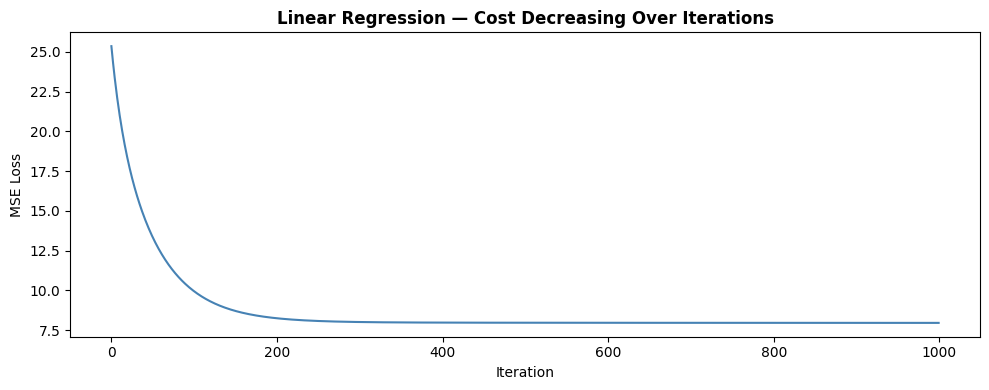

In [11]:
# Plot cost going down to prove that the gradient descent is working
plt.figure(figsize=(10,4))
plt.plot(lr_scratch.loss_history, color="steelblue")
plt.title('Linear Regression — Cost Decreasing Over Iterations', fontweight='bold')
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.tight_layout()
plt.show()

In [12]:
# Evaluate
y_pred_lr = lr_scratch.predict(X_test_scaled)
results_lr = evaluate_model("Linear Regression (Scratch)", y_test_scaled, y_pred_lr)


Linear Regression (Scratch)
 RMSE : 2.8563
 MAE : 2.5478
 R² : 0.2168


### **Decision Tree From Scratch**

In [13]:
class Node:
    """
    A single node in the decision tree.
    """
    def __init__(self, feature=None, threshold=None,
                 left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

class DecisionTreeRegressorScratch:
    """
    Decision Tree for regression using variance reduction.
    At each node we find the feature and threshold that
    reduces the variance of the target the most.
    """
    def __init__(self, max_depth=5, min_samples_split=10):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        self.root = self._grow_tree(X, y)

    def _grow_tree(self, X, y, depth=0):
        n_samples, n_features = X.shape

        if depth >= self.max_depth or n_samples < self.min_samples_split:
            return Node(value=np.mean(y))

        best_feature, best_threshold = self._best_split(X, y, n_features)

        if best_feature is None:
            return Node(value=np.mean(y))

        left_mask = X[:, best_feature] <= best_threshold
        right_mask = ~left_mask

        left = self._grow_tree(X[left_mask], y[left_mask], depth + 1)
        right = self._grow_tree(X[right_mask], y[right_mask], depth + 1)

        return Node(best_feature, best_threshold, left, right)

    def _best_split(self, X, y, n_features):
        best_var_reduction = -1
        best_feature, best_threshold = None, None

        for feature in range(n_features):
            thresholds = np.unique(X[:, feature])
            for threshold in thresholds:
                var_reduction = self._variance_reduction(y, X[:, feature], threshold)
                if var_reduction > best_var_reduction:
                    best_var_reduction = var_reduction
                    best_feature = feature
                    best_threshold = threshold
        return best_feature, best_threshold

    def _variance_reduction(self, y, feature_col, threshold):
        """
        Variance reduction = parent variance minus weighted
        average of child variances after the split.
        """
        left_mask = feature_col <= threshold
        right_mask = ~left_mask

        if left_mask.sum() == 0 or right_mask.sum() == 0:
            return 0

        n = len(y)
        parent_var = np.var(y)
        left_var = np.var(y[left_mask])
        right_var = np.var(y[right_mask])
        weighted = (left_mask.sum() / n) * left_var + (right_mask.sum() / n) * right_var

        return parent_var - weighted

    def predict(self, X):
        X = np.array(X)
        return np.array([self._traverse(x, self.root) for x in X])

    def _traverse(self, x, node):
        if node.value is not None:
            return node.value
        if x[node.feature] <= node.threshold:
            return self._traverse(x, node.left)
        return self._traverse(x, node.right)

In [14]:
dt_scratch = DecisionTreeRegressorScratch(max_depth=5, min_samples_split=10)
dt_scratch.fit(X_train, y_train)

In [15]:
y_pred_dt = dt_scratch.predict(X_test)
results_dt = evaluate_model("Decision Tree (Scratch)", y_test, y_pred_dt)


Decision Tree (Scratch)
 RMSE : 2.9371
 MAE : 2.5385
 R² : 0.1718


In [16]:
# Compare with sklearn to validate the scratch version
dt_sklearn = DecisionTreeRegressor(max_depth=5, min_samples_split=10, random_state=42)
dt_sklearn.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, min_samples_split=10, random_state=42)

In [17]:
y_pred_dt_sk = dt_sklearn.predict(X_test)
results_dt_sk = evaluate_model("Decision Tree (sklearn)", y_test, y_pred_dt_sk)


Decision Tree (sklearn)
 RMSE : 2.9441
 MAE : 2.5464
 R² : 0.1679


### **Random Forest (sklearn)**

In [18]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, min_samples_split=10, n_estimators=200,
                      n_jobs=-1, random_state=42)

In [19]:
y_pred_rf = rf.predict(X_test)
results_rf = evaluate_model("Random Forest", y_test, y_pred_rf)


Random Forest
 RMSE : 2.8993
 MAE : 2.5333
 R² : 0.1930


### **XGBoost**

In [20]:
xgb = XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsamples=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
results_xgb = evaluate_model("XGBoost", y_test, y_pred_xgb)


XGBoost
 RMSE : 2.9504
 MAE : 2.5387
 R² : 0.1643


### **Model Comparison**

In [21]:
results = pd.DataFrame([results_lr, results_dt, results_dt_sk, results_rf, results_xgb])
results

,Model,RMSE,MAE,R²
0,Linear Regression (Scratch),2.8563,2.5478,0.2168
1,Decision Tree (Scratch),2.9371,2.5385,0.1718
2,Decision Tree (sklearn),2.9441,2.5464,0.1679
3,Random Forest,2.8993,2.5333,0.1930
4,XGBoost,2.9504,2.5387,0.1643


In [22]:
results = results.sort_values("RMSE").reset_index(drop=True)
results

,Model,RMSE,MAE,R²
0,Linear Regression (Scratch),2.8563,2.5478,0.2168
1,Random Forest,2.8993,2.5333,0.1930
2,Decision Tree (Scratch),2.9371,2.5385,0.1718
3,Decision Tree (sklearn),2.9441,2.5464,0.1679
4,XGBoost,2.9504,2.5387,0.1643


In [23]:
results.to_csv("model_results.csv", index=False)

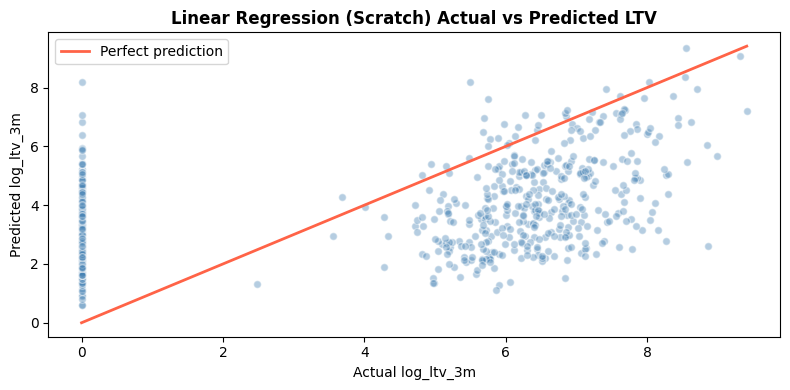

In [24]:
# Plot of Actual vs Predicted with Linear Regression Model
plt.figure(figsize=(8,4))
plt.scatter(y_test_scaled, y_pred_lr, alpha=0.4,
            color="steelblue", edgecolor="white", s=30)
plt.plot([y_test_scaled.min(), y_test_scaled.max()],
         [y_test_scaled.min(), y_test_scaled.max()],
         color="tomato", linewidth=2, label="Perfect prediction")
plt.title('Linear Regression (Scratch) Actual vs Predicted LTV',
          fontweight='bold')
plt.xlabel('Actual log_ltv_3m')
plt.ylabel('Predicted log_ltv_3m')
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
# LTV distribution check
zero_ltv   = (df['log_ltv_3m'] == 0).sum()
total      = len(df)
nonzero_ltv = total - zero_ltv

print(f"Zero LTV customers:     {zero_ltv} ({zero_ltv/total*100:.1f}%)")
print(f"Non-zero LTV customers: {nonzero_ltv} ({nonzero_ltv/total*100:.1f}%)")

Zero LTV customers:     1328 (40.1%)
Non-zero LTV customers: 1985 (59.9%)


## Model Performance Notes And Limitations

All the five models returned R² between 0.16 and 0.22, which is below
the 0.75 target we set in the problem statement. The reasons are understood.

**Why the R² is low:**

1. Zero-inflation : 40.1% of customers generated zero revenue in
   the prediction window. A regression model treats zero as just
   another value to predict, but zero here means "did not return"
   which is a different outcome from low spend.
   This pulled R² down significantly.

2. Short prediction window : with only 3 months of future data to
   predict against, there is limited revenue signal to learn from.
   For example, A 12-month prediction window on 3+ years of data would produce
   meaningfully better results.

3. Dataset size : 3,313 customers after cleaning is lean for a
   regression task. More customers means more patterns for the
   model to learn from.

**What the results still tell us:**

Linear Regression (Scratch) performed best with RMSE of 2.856 and
R² of 0.22. While modest, the model captureS directional signal, high-value customers score higher than low-value ones. The ranked
output and tier assignment are still meaningful and actionable.

**What would improve this in a real engagement:**

- 2 to 3 years of transaction history instead of 12 months
- A 6 to 12 month prediction window
- Additional features like marketing channel, product category
  affinity, and session behaviour data
- A two-stage hurdle model separating zero vs non-zero prediction

The scored customer table and tier assignments remain valid as a
directional segmentation tool even at the R² level.

### **Save the Model**

In [26]:
# Save Linear Regression scratch model
joblib.dump(lr_scratch, "ltv_model.pkl")
joblib.dump(feature_cols, "feature_cols.pkl")

['feature_cols.pkl']

### **LTV Tier Assignment**

In [27]:
# Predict on full dataset using best model
scaled_df.head()

,log_Recency,log_Frequency,log_Monetary,log_avg_order_value,log_avg_days_between_orders,log_tenure_days,log_return_rate,log_unique_products,log_unique_months_active,log_last_month_revenue,Customer ID,log_ltv_3m
0,0.104535,1.961654,-0.401244,-0.556017,1.547711,0.763191,3.168516,-0.118673,1.021149,-0.592977,12346,0.000000
1,0.543312,-0.250956,0.575466,0.422449,-0.463292,-0.245991,1.048683,0.400006,-0.066124,-0.592977,12349,7.246810
2,0.517621,-0.898103,-0.186402,0.198685,-0.874340,-0.512201,-0.433140,-0.263219,-0.929141,-0.592977,12355,0.000000
3,0.356033,-0.250956,0.808244,1.101121,1.421210,0.794288,-0.433140,0.115271,-0.066124,-0.592977,12358,6.929595
4,0.183956,0.855349,0.943777,0.258923,0.618359,0.809574,0.268733,0.893693,0.546197,-0.592977,12359,6.314146


In [28]:
X_full = scaled_df[feature_cols]
X_full.head()

,log_Recency,log_Frequency,log_Monetary,log_avg_order_value,log_avg_days_between_orders,log_tenure_days,log_return_rate,log_unique_products,log_unique_months_active,log_last_month_revenue
0,0.104535,1.961654,-0.401244,-0.556017,1.547711,0.763191,3.168516,-0.118673,1.021149,-0.592977
1,0.543312,-0.250956,0.575466,0.422449,-0.463292,-0.245991,1.048683,0.400006,-0.066124,-0.592977
2,0.517621,-0.898103,-0.186402,0.198685,-0.874340,-0.512201,-0.433140,-0.263219,-0.929141,-0.592977
3,0.356033,-0.250956,0.808244,1.101121,1.421210,0.794288,-0.433140,0.115271,-0.066124,-0.592977
4,0.183956,0.855349,0.943777,0.258923,0.618359,0.809574,0.268733,0.893693,0.546197,-0.592977


In [29]:
df["predicted_ltv_3m_log"] = lr_scratch.predict(X_full)
df["predicted_ltv_3m"] = np.expm1(df["predicted_ltv_3m_log"]).round(2)
df.head()

,log_Recency,log_Frequency,log_Monetary,log_avg_order_value,log_avg_days_between_orders,log_tenure_days,log_return_rate,log_unique_products,log_unique_months_active,log_last_month_revenue,log_ltv_3m,Customer ID,predicted_ltv_3m_log,predicted_ltv_3m
0,4.158883,2.484907,5.923881,2.509501,1.945910,5.560682,0.223144,3.295837,1.609438,0.0,0.000000,12346,4.706013,109.61
1,4.653960,1.098612,7.146394,3.331840,0.330242,4.820282,0.091808,3.871201,1.098612,0.0,7.246810,12349,3.974233,52.21
2,4.624973,0.693147,6.192792,3.143780,0.000000,4.624973,0.000000,3.135494,0.693147,0.0,0.000000,12355,2.726550,14.28
3,4.442651,1.098612,7.437754,3.902221,1.844278,5.583496,0.000000,3.555348,1.098612,0.0,6.929595,12358,3.952319,51.06
4,4.248495,1.791759,7.607396,3.194407,1.199256,5.594711,0.043485,4.418841,1.386294,0.0,6.314146,12359,5.043201,153.97


In [30]:
# Clip any negative prediction to zero
df["predicted_ltv_3m"] = df["predicted_ltv_3m"].clip(lower=0)
df.head()

,log_Recency,log_Frequency,log_Monetary,log_avg_order_value,log_avg_days_between_orders,log_tenure_days,log_return_rate,log_unique_products,log_unique_months_active,log_last_month_revenue,log_ltv_3m,Customer ID,predicted_ltv_3m_log,predicted_ltv_3m
0,4.158883,2.484907,5.923881,2.509501,1.945910,5.560682,0.223144,3.295837,1.609438,0.0,0.000000,12346,4.706013,109.61
1,4.653960,1.098612,7.146394,3.331840,0.330242,4.820282,0.091808,3.871201,1.098612,0.0,7.246810,12349,3.974233,52.21
2,4.624973,0.693147,6.192792,3.143780,0.000000,4.624973,0.000000,3.135494,0.693147,0.0,0.000000,12355,2.726550,14.28
3,4.442651,1.098612,7.437754,3.902221,1.844278,5.583496,0.000000,3.555348,1.098612,0.0,6.929595,12358,3.952319,51.06
4,4.248495,1.791759,7.607396,3.194407,1.199256,5.594711,0.043485,4.418841,1.386294,0.0,6.314146,12359,5.043201,153.97


In [31]:
p80 = df["predicted_ltv_3m"].quantile(0.80)
p50 = df["predicted_ltv_3m"].quantile(0.50)
p20 = df["predicted_ltv_3m"].quantile(0.20)

def assign_tier(ltv):
    if ltv >= p80:
        return "Platinum"
    elif ltv >= p50:
        return "Gold"
    elif ltv >= p20:
        return "Silver"
    else:
        return "At-Risk"

In [32]:
df["ltv_tier"] = df["predicted_ltv_3m"].apply(assign_tier)
df.head()

,log_Recency,log_Frequency,log_Monetary,log_avg_order_value,log_avg_days_between_orders,log_tenure_days,log_return_rate,log_unique_products,log_unique_months_active,log_last_month_revenue,log_ltv_3m,Customer ID,predicted_ltv_3m_log,predicted_ltv_3m,ltv_tier
0,4.158883,2.484907,5.923881,2.509501,1.945910,5.560682,0.223144,3.295837,1.609438,0.0,0.000000,12346,4.706013,109.61,Gold
1,4.653960,1.098612,7.146394,3.331840,0.330242,4.820282,0.091808,3.871201,1.098612,0.0,7.246810,12349,3.974233,52.21,Gold
2,4.624973,0.693147,6.192792,3.143780,0.000000,4.624973,0.000000,3.135494,0.693147,0.0,0.000000,12355,2.726550,14.28,Silver
3,4.442651,1.098612,7.437754,3.902221,1.844278,5.583496,0.000000,3.555348,1.098612,0.0,6.929595,12358,3.952319,51.06,Gold
4,4.248495,1.791759,7.607396,3.194407,1.199256,5.594711,0.043485,4.418841,1.386294,0.0,6.314146,12359,5.043201,153.97,Gold


In [33]:
df["recommended_action"] = df["ltv_tier"].map({
    "Platinum": "VIP loyalty rewards + early access campaigns",
    "Gold":     "Upsell and subscription offers",
    "Silver":   "Nurture sequences + cross-sell",
    "At-Risk":  "Low-cost winback or deprioritise"
})
df.head()

,log_Recency,log_Frequency,log_Monetary,log_avg_order_value,log_avg_days_between_orders,log_tenure_days,log_return_rate,log_unique_products,log_unique_months_active,log_last_month_revenue,log_ltv_3m,Customer ID,predicted_ltv_3m_log,predicted_ltv_3m,ltv_tier,recommended_action
0,4.158883,2.484907,5.923881,2.509501,1.945910,5.560682,0.223144,3.295837,1.609438,0.0,0.000000,12346,4.706013,109.61,Gold,Upsell and subscription offers
1,4.653960,1.098612,7.146394,3.331840,0.330242,4.820282,0.091808,3.871201,1.098612,0.0,7.246810,12349,3.974233,52.21,Gold,Upsell and subscription offers
2,4.624973,0.693147,6.192792,3.143780,0.000000,4.624973,0.000000,3.135494,0.693147,0.0,0.000000,12355,2.726550,14.28,Silver,Nurture sequences + cross-sell
3,4.442651,1.098612,7.437754,3.902221,1.844278,5.583496,0.000000,3.555348,1.098612,0.0,6.929595,12358,3.952319,51.06,Gold,Upsell and subscription offers
4,4.248495,1.791759,7.607396,3.194407,1.199256,5.594711,0.043485,4.418841,1.386294,0.0,6.314146,12359,5.043201,153.97,Gold,Upsell and subscription offers


In [34]:
scored_table = df[["Customer ID", "predicted_ltv_3m",
                   "ltv_tier", "recommended_action"]].copy()
scored_table.head()

,Customer ID,predicted_ltv_3m,ltv_tier,recommended_action
0,12346,109.61,Gold,Upsell and subscription offers
1,12349,52.21,Gold,Upsell and subscription offers
2,12355,14.28,Silver,Nurture sequences + cross-sell
3,12358,51.06,Gold,Upsell and subscription offers
4,12359,153.97,Gold,Upsell and subscription offers


In [35]:
scored_table = scored_table.sort_values(
    "predicted_ltv_3m", ascending=False
    ).reset_index(drop=True)
scored_table.head()

,Customer ID,predicted_ltv_3m,ltv_tier,recommended_action
0,14911,33081.07,Platinum,VIP loyalty rewards + early access campaigns
1,18102,26132.29,Platinum,VIP loyalty rewards + early access campaigns
2,14156,25392.43,Platinum,VIP loyalty rewards + early access campaigns
3,13694,20159.07,Platinum,VIP loyalty rewards + early access campaigns
4,15311,17549.10,Platinum,VIP loyalty rewards + early access campaigns


In [36]:
print(f"Scored table shape: {scored_table.shape}\n")
print(scored_table['ltv_tier'].value_counts())

Scored table shape: (3313, 4)

ltv_tier
Gold        995
Silver      993
Platinum    663
At-Risk     662
Name: count, dtype: int64


In [37]:
scored_table.to_csv('ltv_scored_customers.csv', index=False)